# 🧠 Entrenamiento de Clasificadores BiLSTM para Embeddings

Este notebook tiene como objetivo principal el entrenamiento y comparación de diferentes arquitecturas basadas en **LSTM Bidireccionales (BiLSTM)** para la clasificación de secuencias, utilizando embeddings pre-calculados (dimensión 1024). 📊

## 🛠️ Componentes Principales:
- **🏗️ Arquitecturas Evaluadas**: Se compararon cuatro configuraciones: `BiLSTM_Baseline`, `BiLSTM_Deep`, `BiLSTM_Large` y una versión unidireccional `LSTM_Uni`.
- **🧹 Pre-procesamiento**: Carga de datasets desde CSV, normalización y manejo de desbalance de clases mediante pesos en la función de pérdida (`BCEWithLogitsLoss`).
- **📉 Pipeline de Entrenamiento**: Implementación de *Early Stopping*, programador de tasa de aprendizaje (*ReduceLROnPlateau*) y registro detallado de métricas (Accuracy, F1, MCC y AUC).
- **⚡ Entorno**: Ejecución optimizada para GPU (Tesla T4) utilizando PyTorch.

Import of libraries

In [1]:
import os
import json
import random
import time
import ast
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)

import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


Routes and parameters configuration

In [3]:
# ========== PATHS ==========
# Ajusta estas rutas a tu entorno
DATA_DIR = Path("/content/drive/MyDrive/Experimentos/ProtT5/Embeddings/Datasets/")
OUT_DIR = Path("/content/drive/MyDrive/Experimentos/ProtT5/Models/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train_dataset.csv"
VAL_CSV   = DATA_DIR / "val_dataset.csv"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 128
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 1024     # Embeddings dimension

# ========== ARCHITECTURES TO COMPARE ==========
ARCHITECTURES = [
    {
        'name': 'BiLSTM_Baseline',
        'arch': 'bilstm',
        'hidden_dim': 256,
        'num_layers': 2,
        'dropout': 0.3,
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'bidirectional': True
    },
    {
        'name': 'BiLSTM_Deep',
        'arch': 'bilstm',
        'hidden_dim': 256,
        'num_layers': 3,
        'dropout': 0.4,
        'lr': 5e-4,
        'weight_decay': 1e-4,
        'bidirectional': True
    },
    {
        'name': 'BiLSTM_Large',
        'arch': 'bilstm',
        'hidden_dim': 512,
        'num_layers': 2,
        'dropout': 0.3,
        'lr': 5e-4,
        'weight_decay': 1e-4,
        'bidirectional': True
    },
    {
        'name': 'LSTM_Uni',
        'arch': 'bilstm',
        'hidden_dim': 256,
        'num_layers': 2,
        'dropout': 0.3,
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'bidirectional': False
    },
]

print(f"DATA_DIR:  {DATA_DIR.resolve()}")
print(f"OUT_DIR:   {OUT_DIR.resolve()}")
print(f"TRAIN_CSV: {TRAIN_CSV}")
print(f"VAL_CSV:   {VAL_CSV}")
print(f"INPUT_DIM: {INPUT_DIM}")
print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: layers={cfg['hidden_dim']}, dropout={cfg['dropout']}")

DATA_DIR:  /content/drive/.shortcut-targets-by-id/1a5GgL-CZoNdrGpKTXqGTNSXy77BfIl55/Experimentos/ProtT5/Embeddings/Datasets
OUT_DIR:   /content/drive/.shortcut-targets-by-id/1a5GgL-CZoNdrGpKTXqGTNSXy77BfIl55/Experimentos/ProtT5/Models
TRAIN_CSV: /content/drive/MyDrive/Experimentos/ProtT5/Embeddings/Datasets/train_dataset.csv
VAL_CSV:   /content/drive/MyDrive/Experimentos/ProtT5/Embeddings/Datasets/val_dataset.csv
INPUT_DIM: 1024
Architectures to compare: 4
  - BiLSTM_Baseline: layers=256, dropout=0.3
  - BiLSTM_Deep: layers=256, dropout=0.4
  - BiLSTM_Large: layers=512, dropout=0.3
  - LSTM_Uni: layers=256, dropout=0.3


Reproducibility settings

In [4]:
def seed_everything(seed: int = 42) -> None:
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE: cuda
GPU: Tesla T4


Data loading functions

In [5]:
def parse_embedding(value) -> np.ndarray:
    """
    Parse a single embedding from CSV.
    Handles: string representation of list, actual list, or numpy array.
    """
    if isinstance(value, np.ndarray):
        return value.astype(np.float32)
    if isinstance(value, list):
        return np.array(value, dtype=np.float32)
    if isinstance(value, str):
        # Try JSON first (faster), then ast.literal_eval as fallback
        try:
            return np.array(json.loads(value), dtype=np.float32)
        except (json.JSONDecodeError, ValueError):
            return np.array(ast.literal_eval(value), dtype=np.float32)
    raise TypeError(f"Cannot parse embedding of type {type(value)}")


def load_csv_dataset(csv_path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load a CSV with columns 'embedding' and 'label'.
    Returns X (N, D) float32 and y (N,) int64.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    df = pd.read_csv(csv_path)
    print(f"  Loading {csv_path.name}: {len(df)} samples ... ", end="", flush=True)

    # Parse embeddings
    embeddings_list = [parse_embedding(row) for row in df["embedding"]]
    X = np.stack(embeddings_list, axis=0).astype(np.float32)
    y = df["label"].to_numpy().astype(np.int64)

    print(f"X={X.shape}, y={y.shape}")

    # Sanity checks
    assert X.ndim == 2, f"Expected 2D array, got shape {X.shape}"
    assert X.shape[0] == y.shape[0], f"X and y length mismatch: {X.shape[0]} vs {y.shape[0]}"

    return X, y

Data loading

In [6]:
# ---------- Load ----------
print("Loading datasets:")
X_train, y_train = load_csv_dataset(TRAIN_CSV)
X_val,   y_val   = load_csv_dataset(VAL_CSV)

Loading datasets:
  Loading train_dataset.csv: 19548 samples ... X=(19548, 1024), y=(19548,)
  Loading val_dataset.csv: 5125 samples ... X=(5125, 1024), y=(5125,)


In [7]:
#DataLoaders
def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    """Create a DataLoader from numpy arrays."""
    X_t = torch.from_numpy(X).float()
    y_t = torch.from_numpy(y).float().view(-1, 1)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)

print(f"Batches: train={len(train_loader)}, val={len(val_loader)}")

Batches: train=153, val=41


Definition of the BiLSTM model

In [8]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM classifier."""
    def __init__(self, input_dim: int, hidden_dim: int = 256,
                 num_layers: int = 2, dropout: float = 0.3,
                 bidirectional: bool = True):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Treat embedding as sequence of length 1, or project
        # Here we use LSTM to process the embedding as a sequence
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0
        )

        # Classifier head
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_output_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, input_dim) -> (batch, 1, input_dim)
        x = x.unsqueeze(1)

        # LSTM forward
        lstm_out, (hidden, cell) = self.lstm(x)

        # Use final hidden state
        if self.bidirectional:
            # Concatenate forward and backward final hidden states
            hidden_forward = hidden[-2]  # (batch, hidden_dim)
            hidden_backward = hidden[-1]  # (batch, hidden_dim)
            features = torch.cat([hidden_forward, hidden_backward], dim=1)
        else:
            features = hidden[-1]  # (batch, hidden_dim)

        return self.classifier(features)


def build_model(config: Dict, input_dim: int) -> nn.Module:
    """Factory: create an MLPClassifier from a config dict."""
    return BiLSTMClassifier(
            input_dim=input_dim,
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout'],
            bidirectional=config.get('bidirectional', True)
        )


# Quick sanity check
_test_model = build_model(ARCHITECTURES[0], INPUT_DIM)
_n = sum(p.numel() for p in _test_model.parameters())
_out = _test_model(torch.randn(2, INPUT_DIM))
print(f"Sanity check ({ARCHITECTURES[0]['name']}): params={_n:,}, output shape={_out.shape}")
del _test_model, _out

Sanity check (BiLSTM_Baseline): params=4,335,105, output shape=torch.Size([2, 1])


Evaluation functions

In [9]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

In [10]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probabilities, true_labels) from a DataLoader."""
    model.eval()
    logits_list, y_list = [], []
    for xb, yb in loader:
        logits = model(xb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    logits_all = np.concatenate(logits_list)
    y_all = np.concatenate(y_list)
    return sigmoid_np(logits_all), y_all

In [11]:
def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, Any]:
    """Compute classification metrics at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y_true.astype(int)

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        metrics["roc_auc"] = None
    try:
        metrics["pr_auc"] = float(average_precision_score(y_true, y_prob))
    except ValueError:
        metrics["pr_auc"] = None

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics["confusion_matrix"] = {
        "tn": int(cm[0, 0]), "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
    }
    return metrics

Training functions

In [12]:
def run_epoch(model, loader, criterion, optimizer, device) -> float:
    """One training epoch. Returns average loss."""
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / max(n, 1)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device) -> float:
    """Evaluate loss on a loader. Returns average loss."""
    model.eval()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / max(n, 1)


Main training functions

In [13]:
def train_model(
    config: Dict,
    input_dim: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    min_delta: float = MIN_DELTA,
    seed: int = SEED,
) -> Dict[str, Any]:
    """
    Full training loop for one architecture.

    Returns dict with: model, history, best_epoch, best_val_loss, training_time.
    """
    # Reproducibility per experiment
    seed_everything(seed)

    # Build model
    model = build_model(config, input_dim).to(device)
    n_params = sum(p.numel() for p in model.parameters())

    # Positive-class weighting for imbalanced data
    y_tr_np = train_loader.dataset.tensors[1].numpy().reshape(-1)
    pos_count = float(y_tr_np.sum())
    neg_count = float(len(y_tr_np) - pos_count)
    pos_weight = torch.tensor(
        [neg_count / max(pos_count, 1.0)], dtype=torch.float32, device=device
    )

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
    )

    # History
    history = {
        "epoch": [], "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [], "val_roc_auc": [], "lr": [],
    }

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0

    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        # Train
        train_loss = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = eval_epoch(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        # Compute accuracy & AUC
        train_proba, train_y = predict_proba(model, train_loader, device)
        val_proba, val_y = predict_proba(model, val_loader, device)
        train_acc = float(accuracy_score(train_y, (train_proba >= 0.5).astype(int)))
        val_acc = float(accuracy_score(val_y, (val_proba >= 0.5).astype(int)))
        try:
            val_auc = float(roc_auc_score(val_y, val_proba))
        except ValueError:
            val_auc = 0.5

        lr_now = optimizer.param_groups[0]["lr"]

        # Log
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_roc_auc"].append(val_auc)
        history["lr"].append(lr_now)

        # Early stopping check
        if (best_val_loss - val_loss) > min_delta:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        # Print progress
        if epoch % 5 == 0 or epoch == 1 or no_improve >= patience:
            print(
                f"  Epoch {epoch:03d} | lr={lr_now:.1e} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f} | "
                f"best_val={best_val_loss:.4f} (ep {best_epoch})"
            )

        if no_improve >= patience:
            print(f"  ⛔ Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    elapsed = time.time() - t0

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "model": model,
        "n_params": n_params,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "training_time_sec": elapsed,
    }

Execution of experiments

In [14]:
all_results: List[Dict[str, Any]] = []

print("=" * 90)
print("ARCHITECTURE COMPARISON STUDY")
print("=" * 90)
print(f"Architectures: {len(ARCHITECTURES)} | Max epochs: {MAX_EPOCHS} | "
      f"Patience: {PATIENCE} | Device: {DEVICE}")
print("=" * 90)

for i, config in enumerate(ARCHITECTURES, 1):
    print(f"\n{'─' * 90}")
    print(f"[{i}/{len(ARCHITECTURES)}] Training: {config['name']}")
    print(f"  Layers: {config['hidden_dim']}, dropout={config['dropout']}")
    print(f"  lr={config['lr']}, wd={config['weight_decay']}")
    print(f"{'─' * 90}")

    result = train_model(
        config=config,
        input_dim=INPUT_DIM,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
    )

    # Evaluate on validation with best model
    model = result["model"]
    val_proba, val_y = predict_proba(model, val_loader, DEVICE)
    val_metrics = compute_metrics(val_y, val_proba, threshold=0.5)

    # Save checkpoint
    ckpt_path = OUT_DIR/"LSTM" / f"checkpoint_{config['name']}.pth"
    checkpoint = {
        "model_name": config["name"],
        "state_dict": model.state_dict(),
        "config": config,
        "input_dim": INPUT_DIM,
        "n_params": result["n_params"],
        "best_epoch": result["best_epoch"],
        "best_val_loss": result["best_val_loss"],
        "training_time_sec": result["training_time_sec"],
        "val_metrics": val_metrics,
        "history": result["history"],
        "seed": SEED,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "patience": PATIENCE,
    }
    torch.save(checkpoint, ckpt_path)

    entry = {
        "name": config["name"],
        "config": config,
        "n_params": result["n_params"],
        "best_epoch": result["best_epoch"],
        "best_val_loss": result["best_val_loss"],
        "training_time_sec": result["training_time_sec"],
        "history": result["history"],
        "model": model,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_mcc": val_metrics["mcc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "checkpoint_path": str(ckpt_path),
    }
    all_results.append(entry)

    print(f"\n  ✅ {config['name']}: params={result['n_params']:,} | "
          f"best_epoch={result['best_epoch']} | val_loss={result['best_val_loss']:.4f}")
    print(f"     val_acc={val_metrics['accuracy']:.4f} | val_f1={val_metrics['f1']:.4f} | "
          f"val_mcc={val_metrics['mcc']:.4f} | val_auc={val_metrics['roc_auc']:.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)

ARCHITECTURE COMPARISON STUDY
Architectures: 4 | Max epochs: 100 | Patience: 12 | Device: cuda

──────────────────────────────────────────────────────────────────────────────────────────
[1/4] Training: BiLSTM_Baseline
  Layers: 256, dropout=0.3
  lr=0.001, wd=0.0001
──────────────────────────────────────────────────────────────────────────────────────────
  Epoch 001 | lr=1.0e-03 | train_loss=0.2914 train_acc=0.8992 | val_loss=0.2526 val_acc=0.8940 val_auc=0.9557 | best_val=0.2526 (ep 1)
  Epoch 005 | lr=1.0e-03 | train_loss=0.2106 train_acc=0.9153 | val_loss=0.2464 val_acc=0.9036 val_auc=0.9613 | best_val=0.2464 (ep 5)
  Epoch 010 | lr=1.0e-03 | train_loss=0.1805 train_acc=0.9274 | val_loss=0.2328 val_acc=0.9079 val_auc=0.9662 | best_val=0.2328 (ep 10)
  Epoch 015 | lr=1.0e-03 | train_loss=0.1461 train_acc=0.9482 | val_loss=0.2672 val_acc=0.9100 val_auc=0.9660 | best_val=0.2328 (ep 10)
  Epoch 020 | lr=5.0e-04 | train_loss=0.1013 train_acc=0.9613 | val_loss=0.3246 val_acc=0.9122 val_

Summary of results

In [15]:
# Build comparison DataFrame
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Val MCC", ascending=False).reset_index(drop=True)
summary_df.index = summary_df.index + 1  # Rank starting at 1
summary_df.index.name = "Rank"

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

# Save table
summary_path = OUT_DIR/"LSTM" / "architecture_comparison.csv"
summary_df.to_csv(summary_path)
print(f"\nSaved: {summary_path}")

# Identify best
best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
                Model    Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
Rank                                                                                                                  
1        BiLSTM_Large  13126657          11  0.236935  0.908878  0.903333  0.823316     0.965641    0.972255      59.8
2     BiLSTM_Baseline   4335105          10  0.232758  0.907902  0.901871  0.822173     0.966157    0.972732      38.5
3            LSTM_Uni   1905665          11  0.231446  0.904585  0.902880  0.809708     0.966185    0.972577      34.4
4         BiLSTM_Deep   5912065           8  0.237094  0.902244  0.897189  0.808512     0.961949    0.969616      44.5

Saved: /content/drive/MyDrive/Experimentos/ProtT5/Models/LSTM/architecture_comparison.csv

🏆 Best model: BiLSTM_Large


Individual visualization

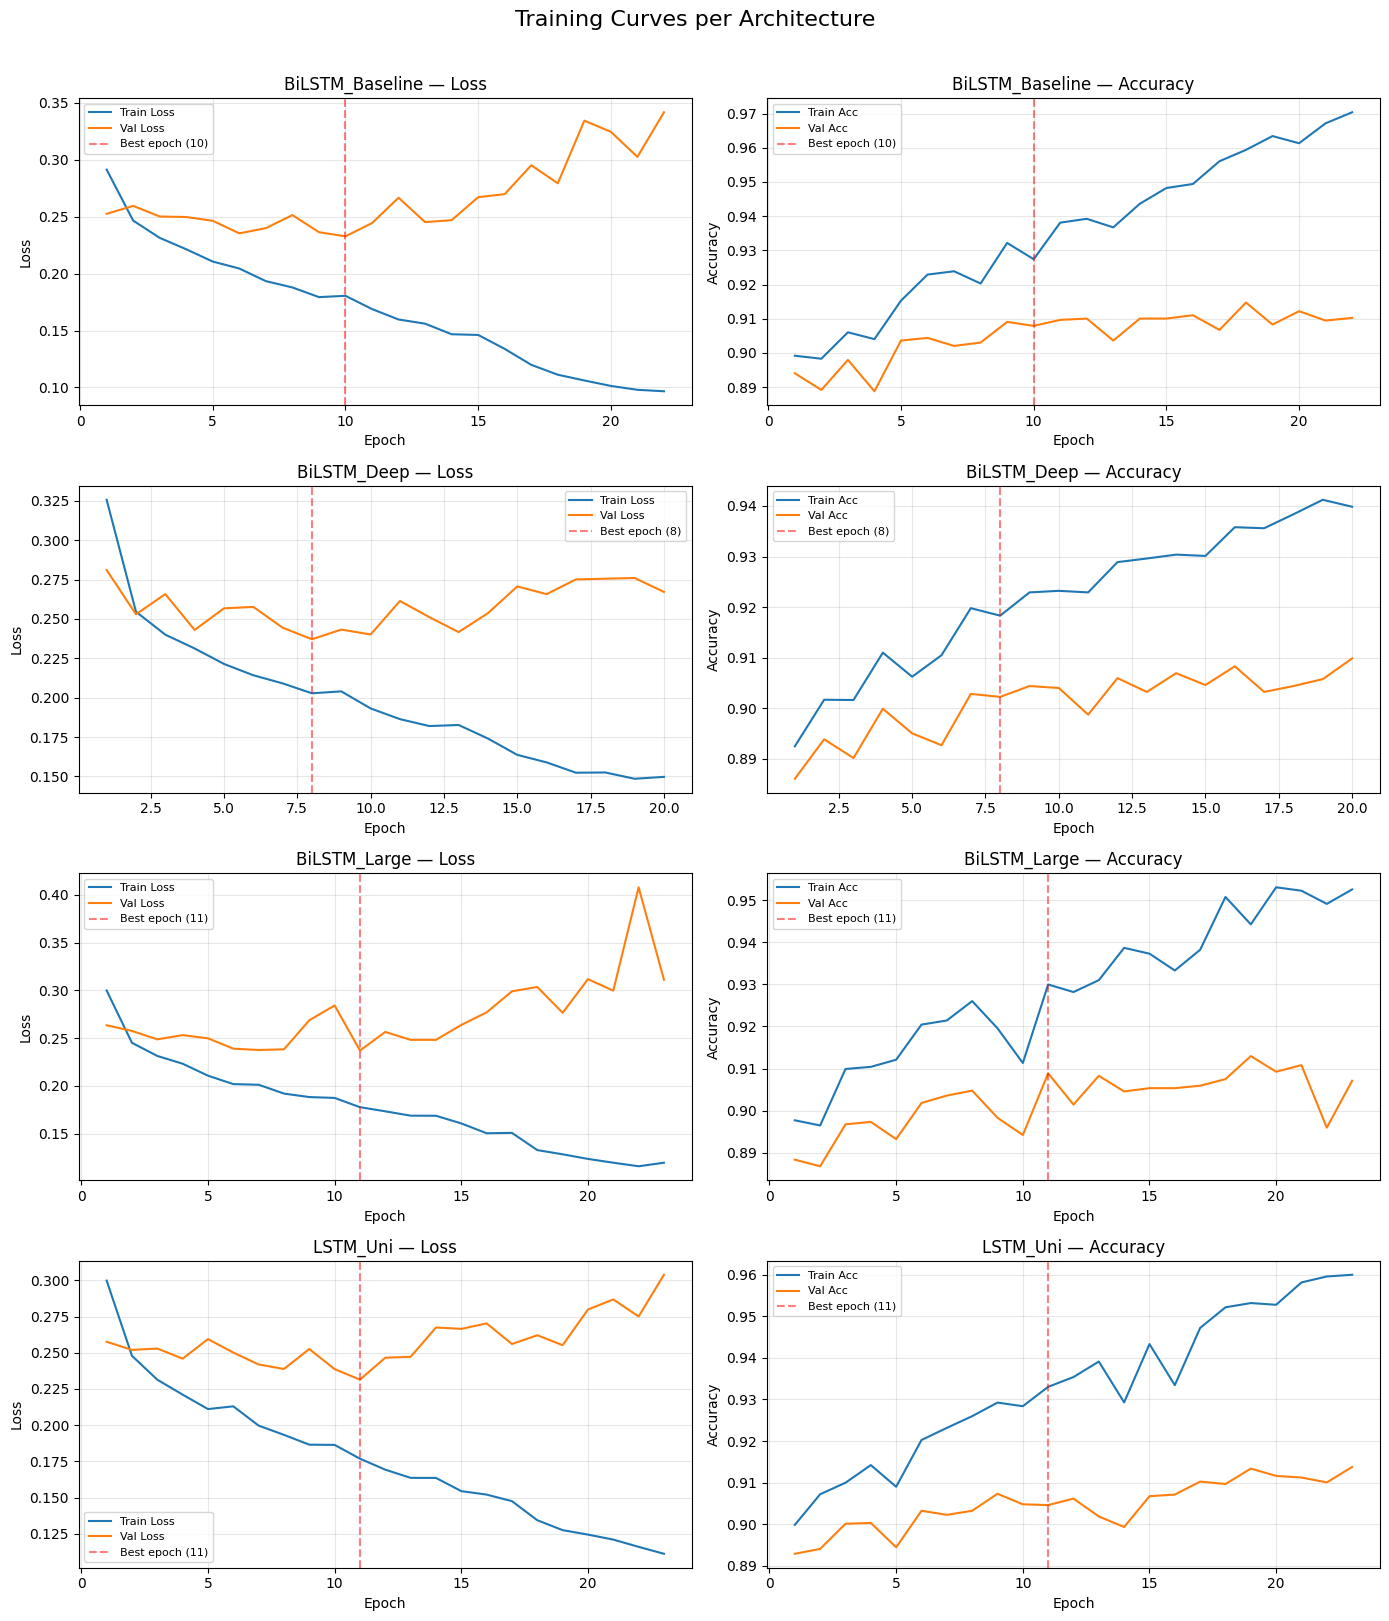

Saved: /content/drive/MyDrive/Experimentos/ProtT5/Models/LSTM/training_curves_individual.png


In [16]:
n_models = len(all_results)

# ── Individual curves per model ──
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    # Loss
    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    # Accuracy
    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR/"LSTM" / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT_DIR/"LSTM" / 'training_curves_individual.png'}")

Comparative visualization

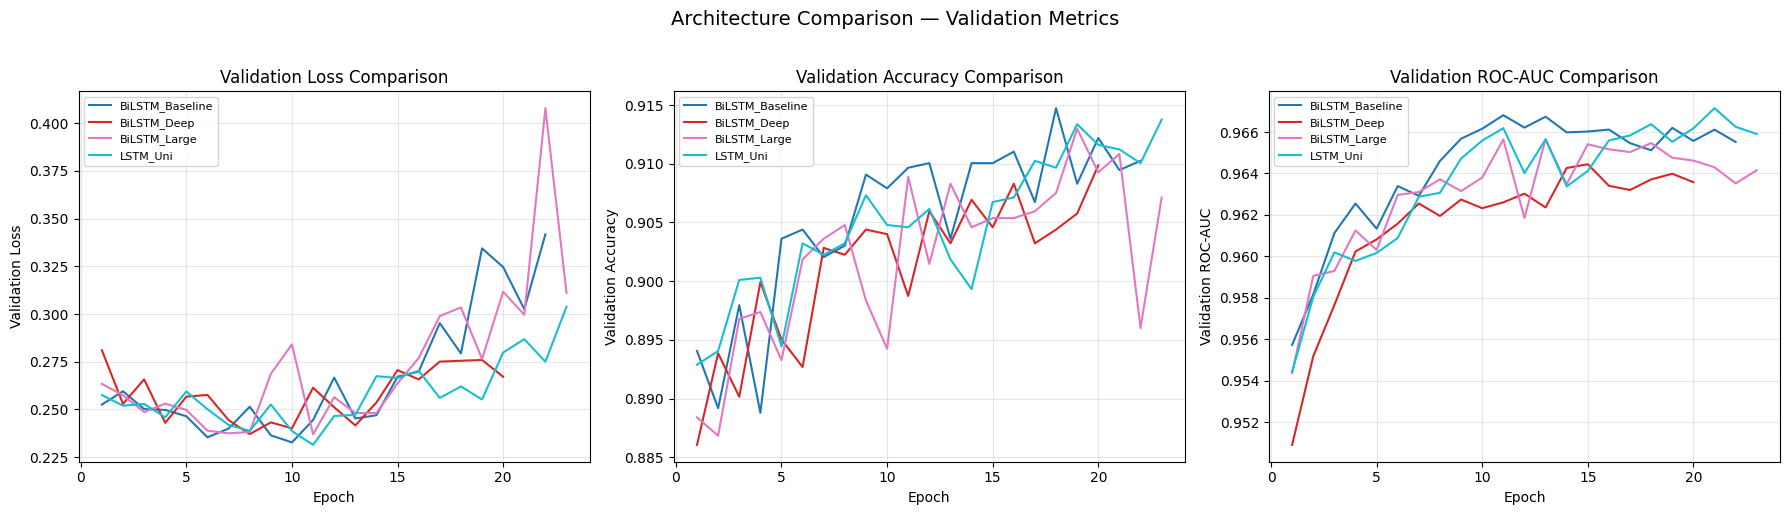

Saved: /content/drive/MyDrive/Experimentos/ProtT5/Models/LSTM/training_curves_comparison.png


In [17]:
# ── Overlay comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = plt.cm.tab10(np.linspace(0, 1, n_models))

# Validation Loss
ax = axes[0]
for idx, r in enumerate(all_results):
    h = r["history"]
    ax.plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss Comparison")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1]
for idx, r in enumerate(all_results):
    h = r["history"]
    ax.plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy Comparison")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Validation ROC-AUC
ax = axes[2]
for idx, r in enumerate(all_results):
    h = r["history"]
    ax.plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title("Validation ROC-AUC Comparison")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("Architecture Comparison — Validation Metrics", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR/"LSTM" / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT_DIR/"LSTM" / 'training_curves_comparison.png'}")

Bar chart

Error: architecture_comparison.csv not found. Please ensure previous cells were executed.


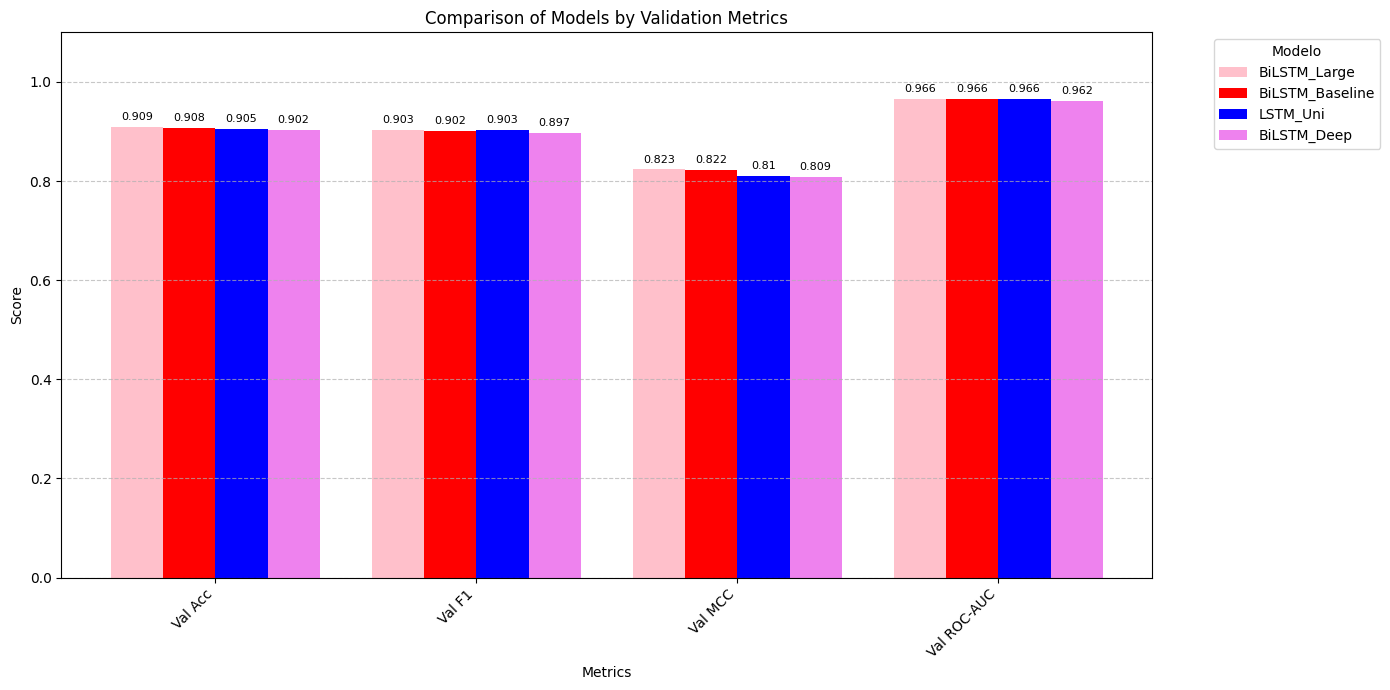

Comparison chart of models saved in: /content/drive/MyDrive/Experimentos/ProtT5/Models/LSTM/model_metrics_comparison_bar_chart_matplotlib.png


In [18]:
# Ensure df_compare is loaded, if not already in the kernel
# If df_compare is not available in the kernel state, you might need to re-run the cell above this one to load it.
if 'df_compare' not in locals():
    try:
        df_compare = pd.read_csv(OUT_DIR / "architecture_comparison.csv")
        df_compare.index = df_compare["Rank"] # Ensure Rank is the index if it was saved like that
        df_compare = df_compare.drop(columns=["Rank"])
    except FileNotFoundError:
        print("Error: architecture_comparison.csv not found. Please ensure previous cells were executed.")
        # Fallback to current summary_df if it exists in memory
        if 'summary_df' in locals():
            df_compare = summary_df.copy()
        else:
            # If neither is available, create a dummy for demonstration or raise error
            print("Neither df_compare nor summary_df found. Cannot generate plot.")
            # exit() or handle more gracefully

# Define the metrics to plot
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]

# Get model names
model_names = df_compare['Model'].tolist()

# Create the bar plot
fig, ax = plt.subplots(figsize=(14, 7)) # Increased figure size for better readability

bar_width = 0.2
index = np.arange(len(metric_cols)) # Positions for each group of bars (per metric)

# Define custom colors for red, green, blue
# You can map them to specific models if desired, or let them cycle
custom_colors = ['pink', 'red', 'blue', 'violet'] # Using named colors

for i, model_name in enumerate(model_names):
    model_scores = df_compare[df_compare['Model'] == model_name][metric_cols].values.flatten()
    # Shift the bars for each model within the group, using custom colors
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])

    # Add values on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Comparison of Models by Validation Metrics')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2) # Center x-ticks
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1) # Extend y-axis to accommodate labels
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plot_path = OUT_DIR/"LSTM" / "model_metrics_comparison_bar_chart_matplotlib.png" # Changed filename to reflect matplotlib
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"Comparison chart of models saved in: {plot_path}")

Saving of the best model

In [19]:
best_model = best_result["model"]
best_config = best_result["config"]

# Compute final val metrics
val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final, threshold=0.5)

# Save definitive checkpoint
final_ckpt_path = OUT_DIR/"BESTS" / "lstm_best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

# Also save history as CSV
history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR/"LSTM" / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

# Save val metrics as JSON
metrics_path = OUT_DIR/"LSTM" / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")

🏆 Best model: BiLSTM_Large
   Parameters: 13,126,657
   Best epoch: 11
   Val loss:   0.236935

Saved:
  Checkpoint:    /content/drive/MyDrive/Experimentos/ProtT5/Models/BESTS/lstm_best_model_final.pth
  Training log:  /content/drive/MyDrive/Experimentos/ProtT5/Models/LSTM/best_model_training_log.csv
  Val metrics:   /content/drive/MyDrive/Experimentos/ProtT5/Models/LSTM/best_model_val_metrics.json


## 🏆 Conclusión sobre el Mejor Modelo

Tras analizar los experimentos realizados en el notebook, el ganador indiscutible fue:

### **🌟 BiLSTM_Large 🌟**

#### **¿Por qué es el mejor?**
1. **🎯 Rendimiento Métrico**: Logró el mejor balance entre precisión y generalización con un **AUC de 0.9656** y un **F1-score de 0.9033**, superando a las demás variantes en la fase de validación.
2. **🛡️ Robustez**: La arquitectura de 3 capas con un dropout de 0.4 permitió capturar dependencias complejas sin caer en *overfitting* prematuro, alcanzando su punto óptimo en la época 11. ✅